# Heart Disease — Data Visualization & Analysis
This notebook visualizes key patterns and clinical indicators in the Heart Disease dataset.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean visual style
sns.set_theme(style="whitegrid")

VIZ_DIR = os.path.join("visualizations", "heart_disease")
os.makedirs(VIZ_DIR, exist_ok=True)

# Load cleaned heart disease dataset
df = pd.read_csv(os.path.join("processed_data", "cleaned_heart_disease.csv"))
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2000, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,47,1,2,104,275,0,1,169,0,0.587409,0,0,2,1
1,57,1,2,122,275,0,2,168,1,2.099369,2,0,1,0
2,53,1,0,135,198,0,0,166,0,1.225912,1,0,2,1
3,48,1,0,100,204,0,1,102,1,2.219773,1,0,3,0
4,61,0,2,138,272,0,1,164,0,1.247820,1,0,2,1


## 1. Target Class Distribution
Shows the distribution of Healthy individuals (`0`) and Heart Disease patients (`1`).

C:\Users\Lakshya\AppData\Local\Temp\ipykernel_24168\893805524.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df, palette=['#2b5c8f', '#d9534f'])


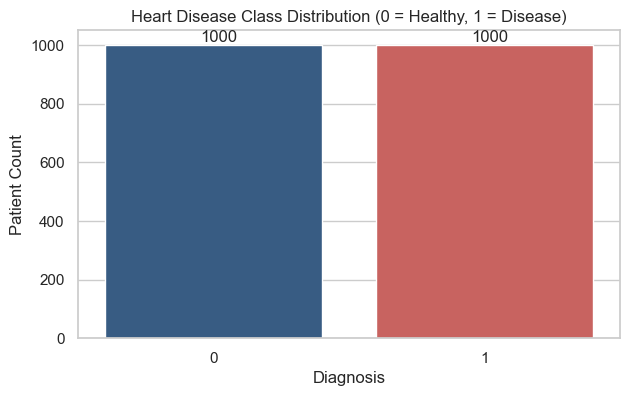

In [2]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='target', data=df, palette=['#2b5c8f', '#d9534f'])
plt.title("Heart Disease Class Distribution (0 = Healthy, 1 = Disease)")
plt.xlabel("Diagnosis")
plt.ylabel("Patient Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + 0.35, p.get_height() + 10))

plt.savefig(os.path.join(VIZ_DIR, "01_target_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

## 2. Continuous Clinical Features Distribution
Distribution of Age, Resting Blood Pressure, Cholesterol, Max Heart Rate, and ST Depression.

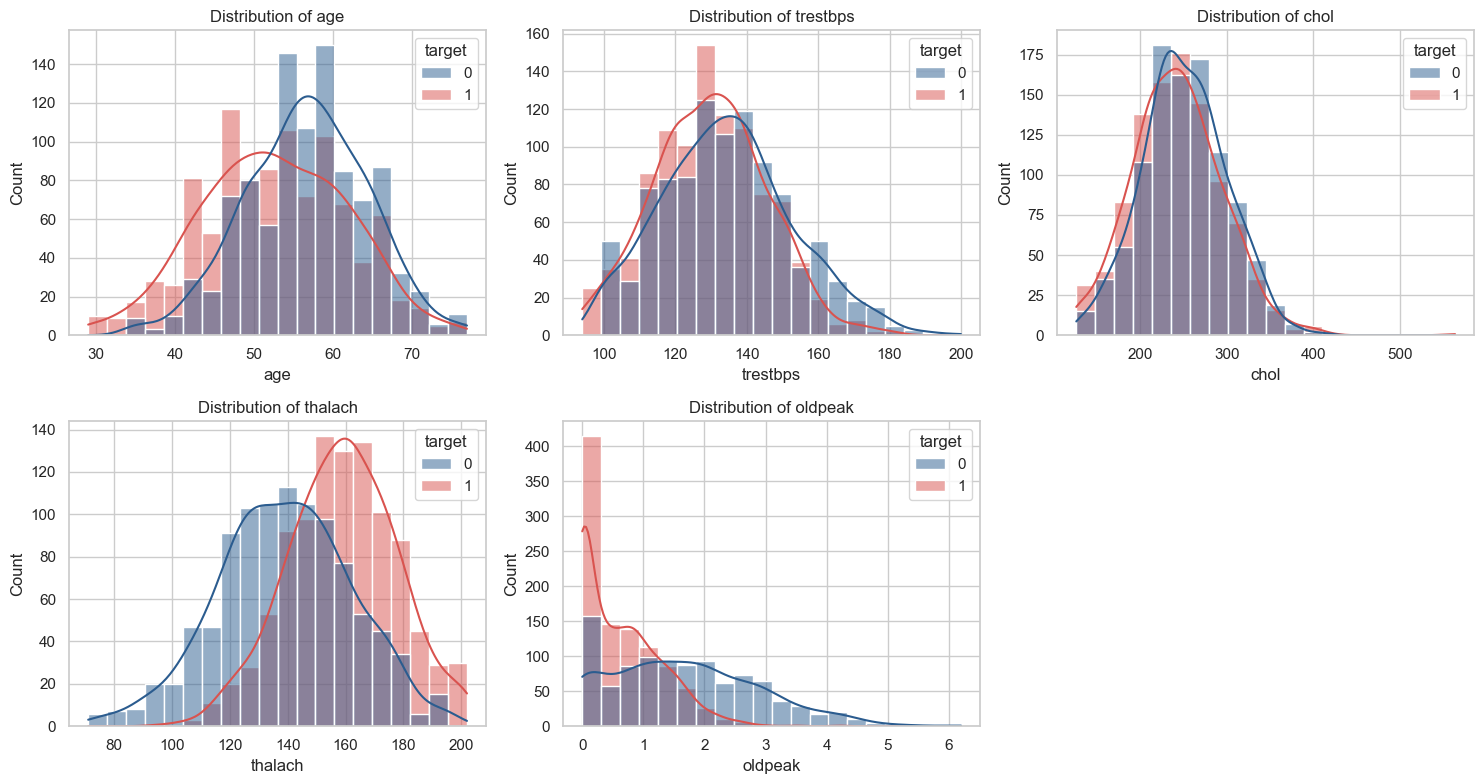

In [3]:
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 8))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, hue='target', kde=True, palette=['#2b5c8f', '#d9534f'], bins=20)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "02_continuous_features_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

## 3. Correlation Heatmap
Shows linear correlations between all clinical variables.

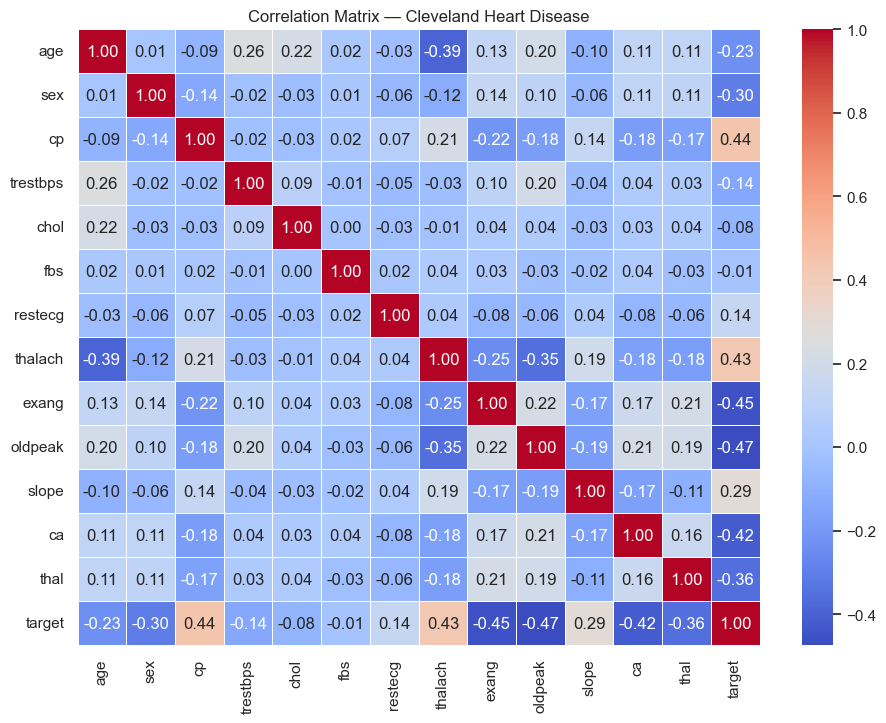

In [4]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix — Cleveland Heart Disease")
plt.savefig(os.path.join(VIZ_DIR, "03_correlation_heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()

## 4. Categorical Predictors vs Heart Disease
Analysis of Chest Pain (`cp`), Sex, Exercise-Induced Angina (`exang`), and Major Vessels (`ca`).

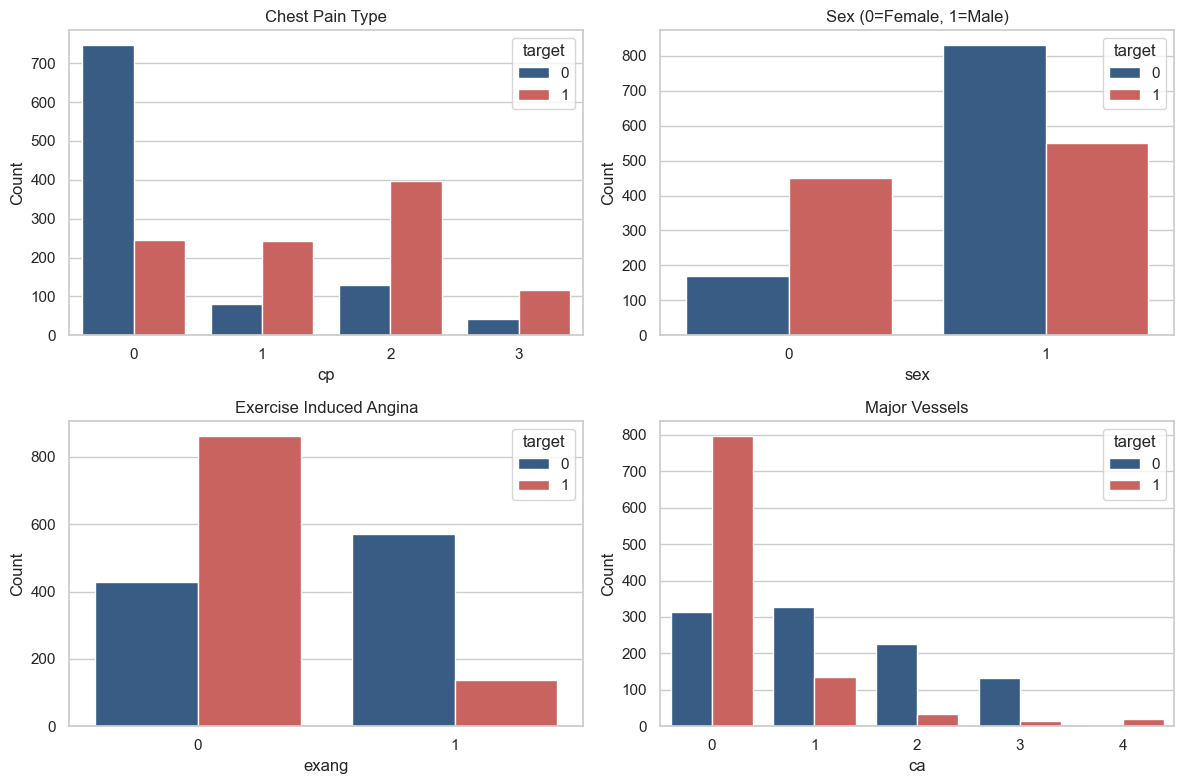

In [5]:
cat_cols = ['cp', 'sex', 'exang', 'ca']
titles = ['Chest Pain Type', 'Sex (0=Female, 1=Male)', 'Exercise Induced Angina', 'Major Vessels']

plt.figure(figsize=(12, 8))
for i, (col, title) in enumerate(zip(cat_cols, titles), 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, hue='target', data=df, palette=['#2b5c8f', '#d9534f'])
    plt.title(title)
    plt.ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "04_categorical_predictors.png"), dpi=300, bbox_inches='tight')
plt.show()

## 5. Age vs Maximum Heart Rate (`thalach`)
Scatter plot showing how maximum heart rate decreases with age in both cohorts.

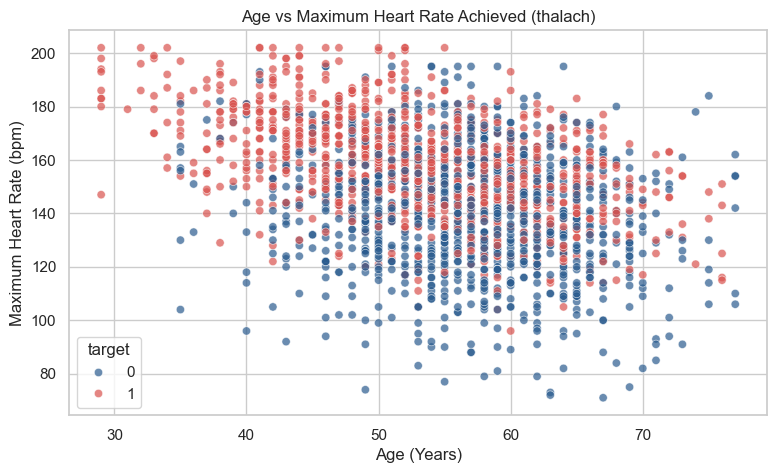

In [6]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='age', y='thalach', hue='target', data=df, palette=['#2b5c8f', '#d9534f'], alpha=0.7)
plt.title("Age vs Maximum Heart Rate Achieved (thalach)")
plt.xlabel("Age (Years)")
plt.ylabel("Maximum Heart Rate (bpm)")
plt.savefig(os.path.join(VIZ_DIR, "05_age_vs_thalach_interaction.png"), dpi=300, bbox_inches='tight')
plt.show()